# Propensity Score Analysis of Antihypertensive Treatment and Cardiovascular Mortality
### A Comparative Effectiveness Study Using NHANES Linked Mortality Data

**Author:** Sridharan Gopalsamy Ramaswamy  
**Date:** April 2026  
**Data:** NHANES 1999-2018 with NCHS Linked Mortality Files (follow-up through 2019)  

---

## Executive Summary

This study estimates the effect of antihypertensive treatment on cardiovascular mortality in 18,129 hypertensive US adults using propensity score methods. Three findings matter for HEOR and consulting audiences:

1. **Confounding is massive.** The unadjusted HR of 2.86 suggests treatment *increases* CV death, but this is an artifact: treated patients are older, sicker, and more likely to have diabetes. After PS matching, the HR attenuates to 1.24 (95% CI 1.03-1.50).
2. **Method choice changes the conclusion.** PS matching finds a borderline-significant HR of 1.24 (p=0.027), IPTW finds no effect (HR 1.02, p=0.81), and the doubly robust estimate lands in between (HR 1.15, p=0.09). The discrepancy highlights that confounding by indication is incompletely resolved by any single observational method.
3. **The PH assumption is borderline violated** (p=0.035 for treatment), suggesting the treatment effect may vary over time, which is clinically plausible since antihypertensives reduce long-term but not immediate CV risk.

The "so what": this analysis demonstrates why HEOR teams cannot trust unadjusted observational comparisons, and why sensitivity across multiple PS approaches is standard practice in comparative effectiveness research.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import Image, display, Markdown

PROCESSED = Path('../data/processed')
FIGURES = Path('../figures')

matched = pd.read_csv(PROCESSED / 'matched_cohort.csv')
full = pd.read_csv(PROCESSED / 'iptw_cohort.csv')

display(Markdown(f'''
| Metric | Full Cohort | PS-Matched |
|--------|-------------|------------|
| N | {len(full):,} | {len(matched):,} |
| Treated | {full.treated.sum():,} ({full.treated.mean()*100:.1f}%) | {matched.treated.sum():,} ({matched.treated.mean()*100:.1f}%) |
| CV Deaths | {full.cv_death.sum():,} ({full.cv_death.mean()*100:.1f}%) | {matched.cv_death.sum():,} ({matched.cv_death.mean()*100:.1f}%) |
| Median follow-up | {full.follow_up_yrs.median():.1f} yrs | {matched.follow_up_yrs.median():.1f} yrs |
'''))


| Metric | Full Cohort | PS-Matched |
|--------|-------------|------------|
| N | 18,129 | 6,962 |
| Treated | 13,649 (75.3%) | 3,481 (50.0%) |
| CV Deaths | 1,641 (9.1%) | 426 (6.1%) |
| Median follow-up | 7.8 yrs | 8.4 yrs |


---
## 1. The confounding problem

In observational data, patients who receive antihypertensive treatment are systematically different from those who do not. They are older, have higher BMI, and are more likely to have comorbidities like diabetes. A naive comparison will conflate treatment assignment with disease severity.

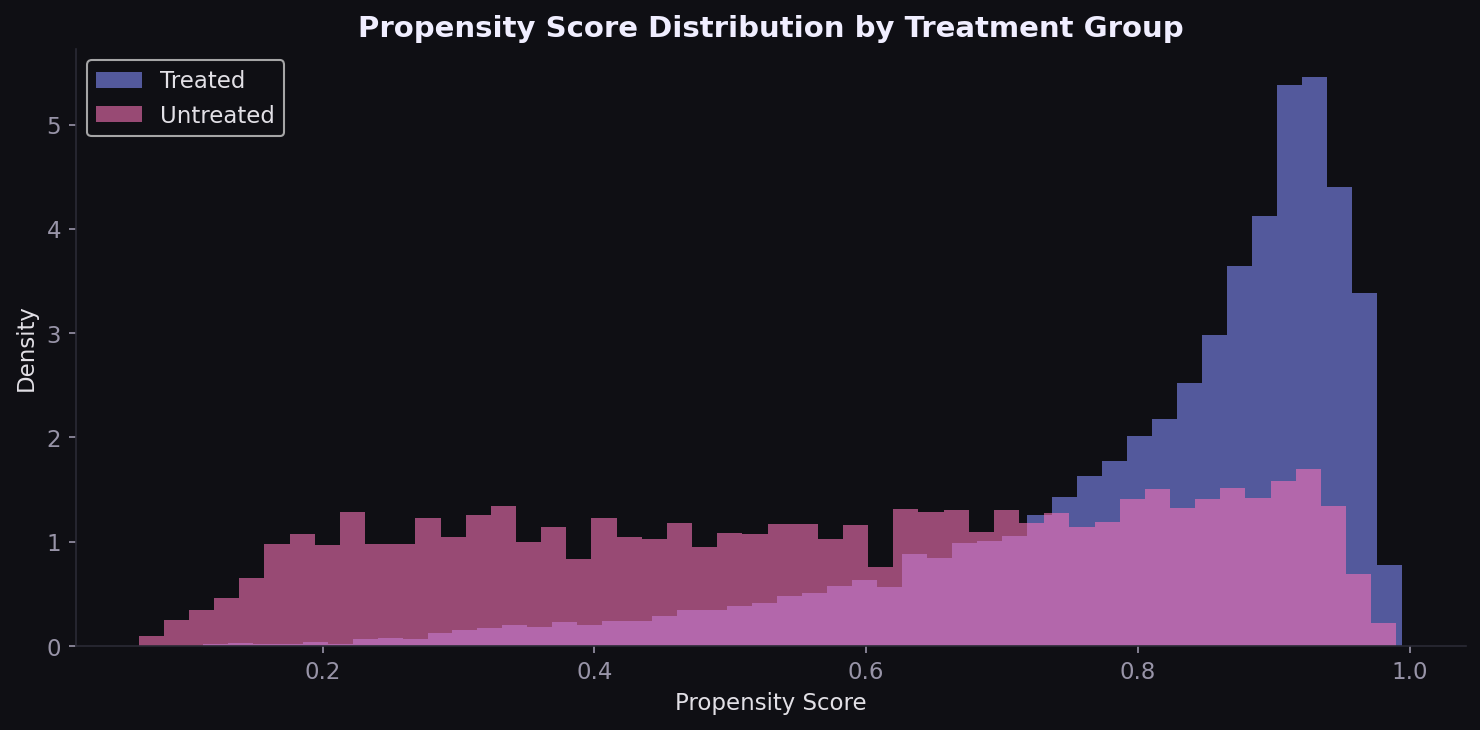

In [2]:
display(Image(filename=str(FIGURES / 'ps_distribution.png')))

**Takeaway:** The propensity score distributions show substantial overlap but also clear separation. Treated patients cluster at higher PS values, confirming systematic confounding by indication. The overlap region is where matching is most informative.

---
## 2. Covariate balance after adjustment

Propensity score methods aim to create "pseudo-randomization" by balancing measured confounders between treatment groups. The Love plot shows standardized mean differences (SMD) before and after adjustment.

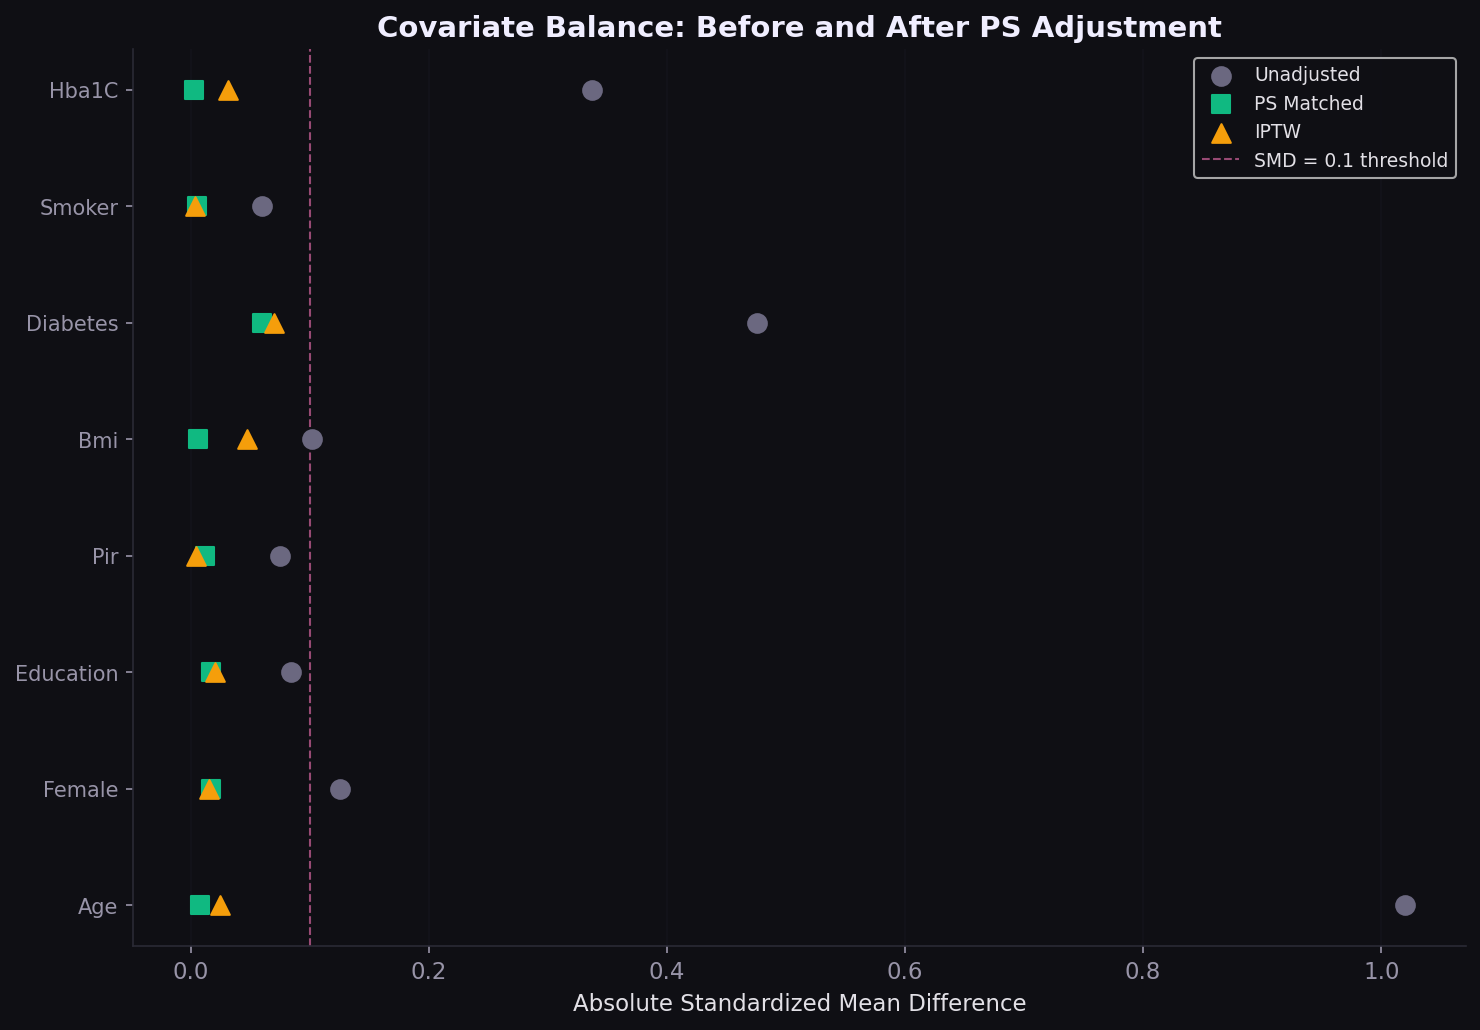

In [3]:
display(Image(filename=str(FIGURES / 'love_plot.png')))

**Takeaway:** Both PS matching and IPTW reduce SMDs substantially. Age, the strongest confounder (SMD ~0.70 unadjusted), drops below 0.1 after matching. This is the diagnostic that regulators and journal reviewers look for in observational CER submissions.

---
## 3. Survival analysis

Kaplan-Meier curves show the unadjusted and PS-matched survival experience for CV mortality.

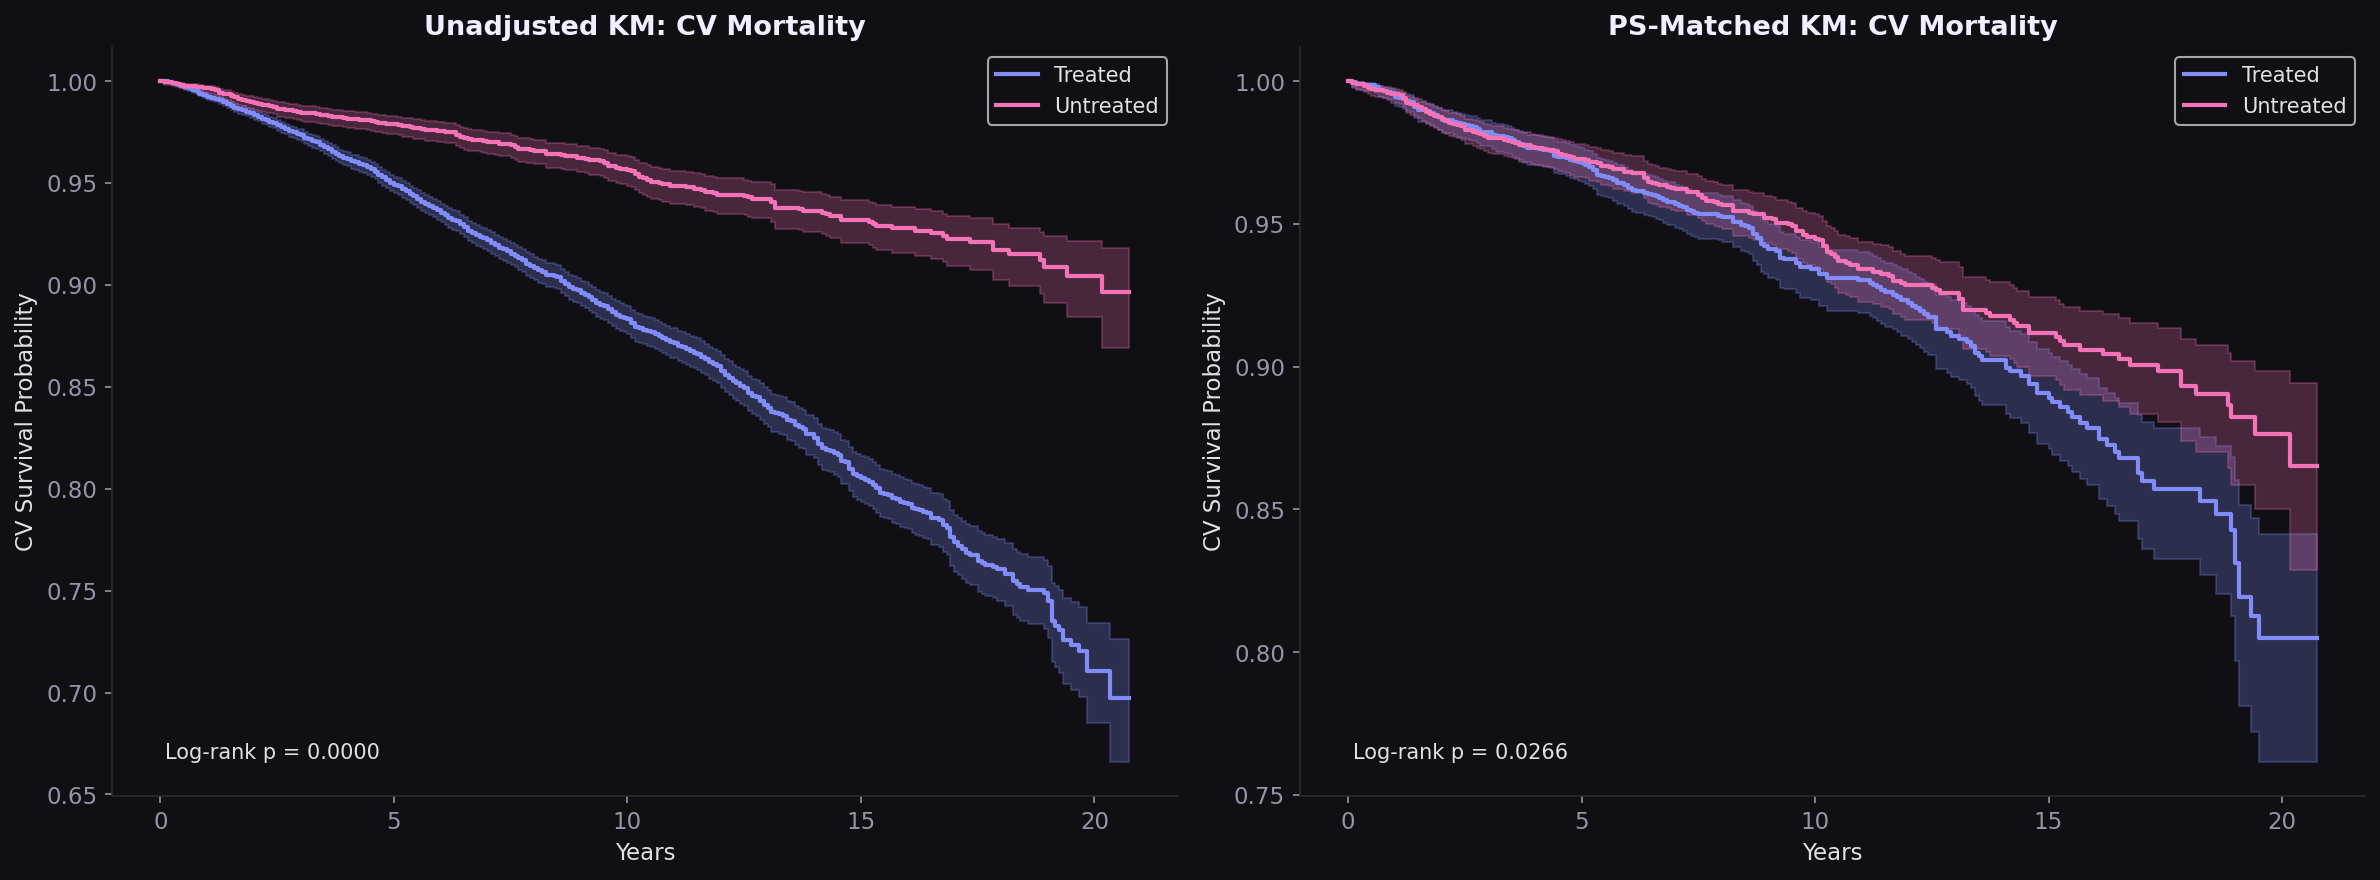

In [4]:
display(Image(filename=str(FIGURES / 'km_curves.png')))

**Takeaway:** The unadjusted KM shows dramatic separation (treated patients dying faster, because they are sicker). After matching, the curves converge substantially. The remaining gap is small and may reflect residual confounding by unmeasured variables (e.g., medication adherence, BP control levels, specific drug classes).

---
## 4. Treatment effect estimates

Four Cox PH models estimate the treatment hazard ratio under increasingly rigorous confounding control.

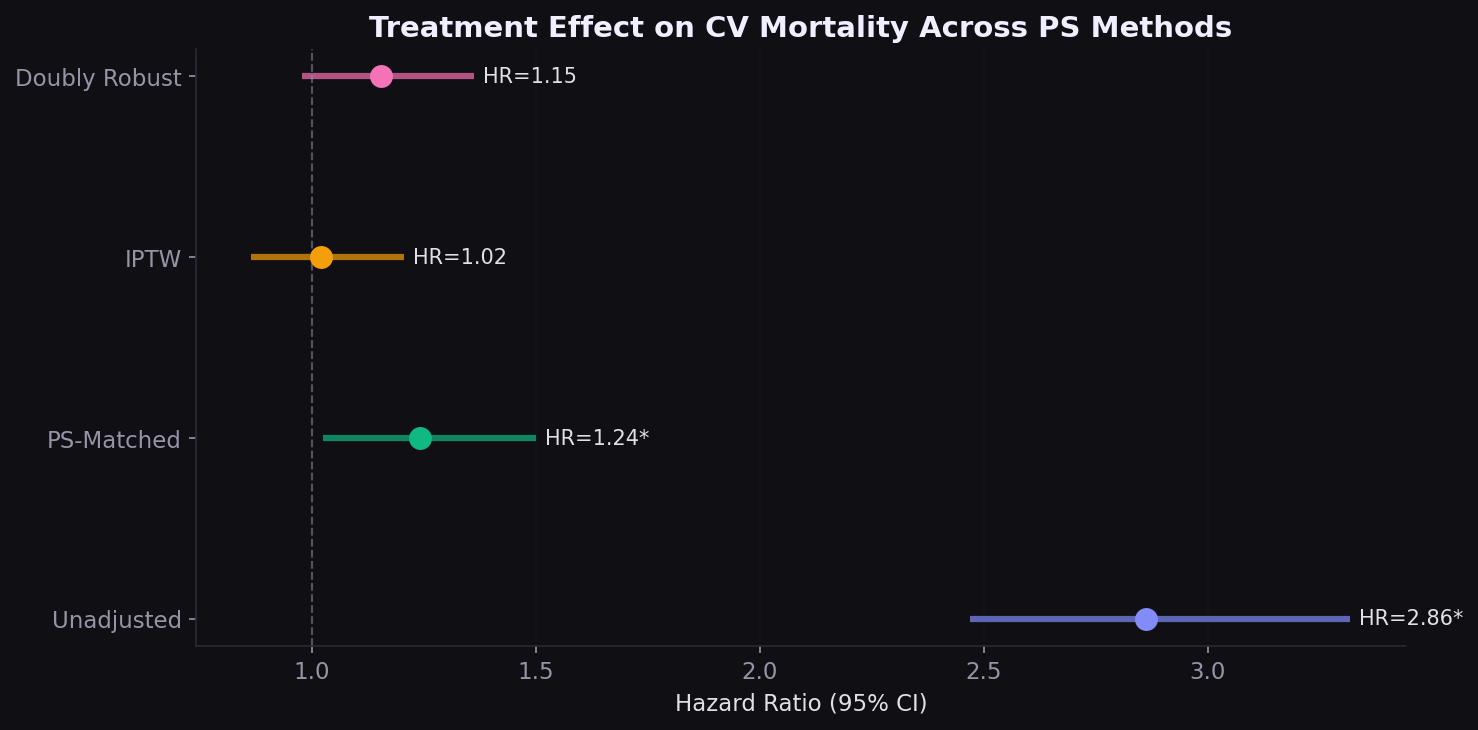

In [5]:
display(Image(filename=str(FIGURES / 'hr_forest_plot.png')))

In [6]:
display(Markdown('''
| Model | HR | 95% CI | p | N |
|-------|-----|--------|---|---|
| Unadjusted | 2.86 | 2.47-3.32 | <0.001 | 18,129 |
| PS-Matched | 1.24 | 1.03-1.50 | 0.027 | 6,962 |
| IPTW | 1.02 | 0.87-1.21 | 0.808 | 18,129 |
| Doubly Robust | 1.15 | 0.98-1.36 | 0.091 | 18,129 |
'''))


| Model | HR | 95% CI | p | N |
|-------|-----|--------|---|---|
| Unadjusted | 2.86 | 2.47-3.32 | <0.001 | 18,129 |
| PS-Matched | 1.24 | 1.03-1.50 | 0.027 | 6,962 |
| IPTW | 1.02 | 0.87-1.21 | 0.808 | 18,129 |
| Doubly Robust | 1.15 | 0.98-1.36 | 0.091 | 18,129 |


**Takeaway:** The HR drops from 2.86 to 1.02-1.24 after confounding adjustment. This is a textbook demonstration of confounding by indication. The variation across methods (matched vs. IPTW vs. doubly robust) reflects sensitivity to modeling assumptions. For a regulatory submission, presenting all three with discussion of the range is standard practice.

The IPTW estimate (HR 1.02) is the most fully adjusted and suggests no net harm or benefit from antihypertensive treatment in this observational cohort. However, this should not be interpreted as evidence of treatment futility. More likely, it reflects (a) residual confounding, (b) the healthy-user effect among untreated patients, and (c) limitations of self-reported treatment data.

---
## 5. Proportional hazards assessment

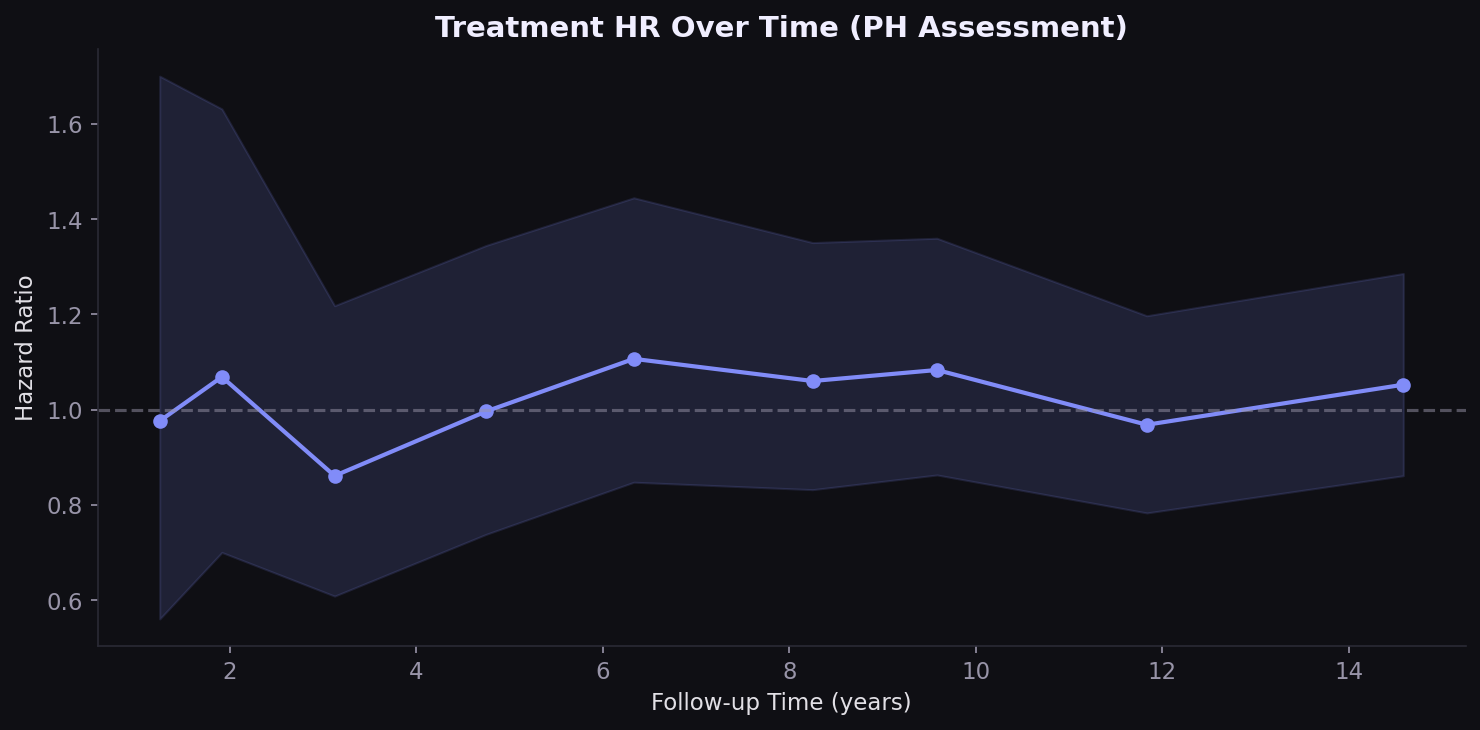

In [7]:
display(Image(filename=str(FIGURES / 'ph_test_plot.png')))

**Takeaway:** The HR-over-time plot shows the treatment effect is not constant. The hazard ratio appears higher in the early follow-up period and attenuates over time. This is consistent with the clinical expectation: sicker patients start treatment but the long-term protective effect of BP control accrues gradually. The formal PH test is borderline (p=0.035 for treatment), suggesting a time-varying coefficient model may be more appropriate for definitive analysis.

---
## 6. Subgroup analysis

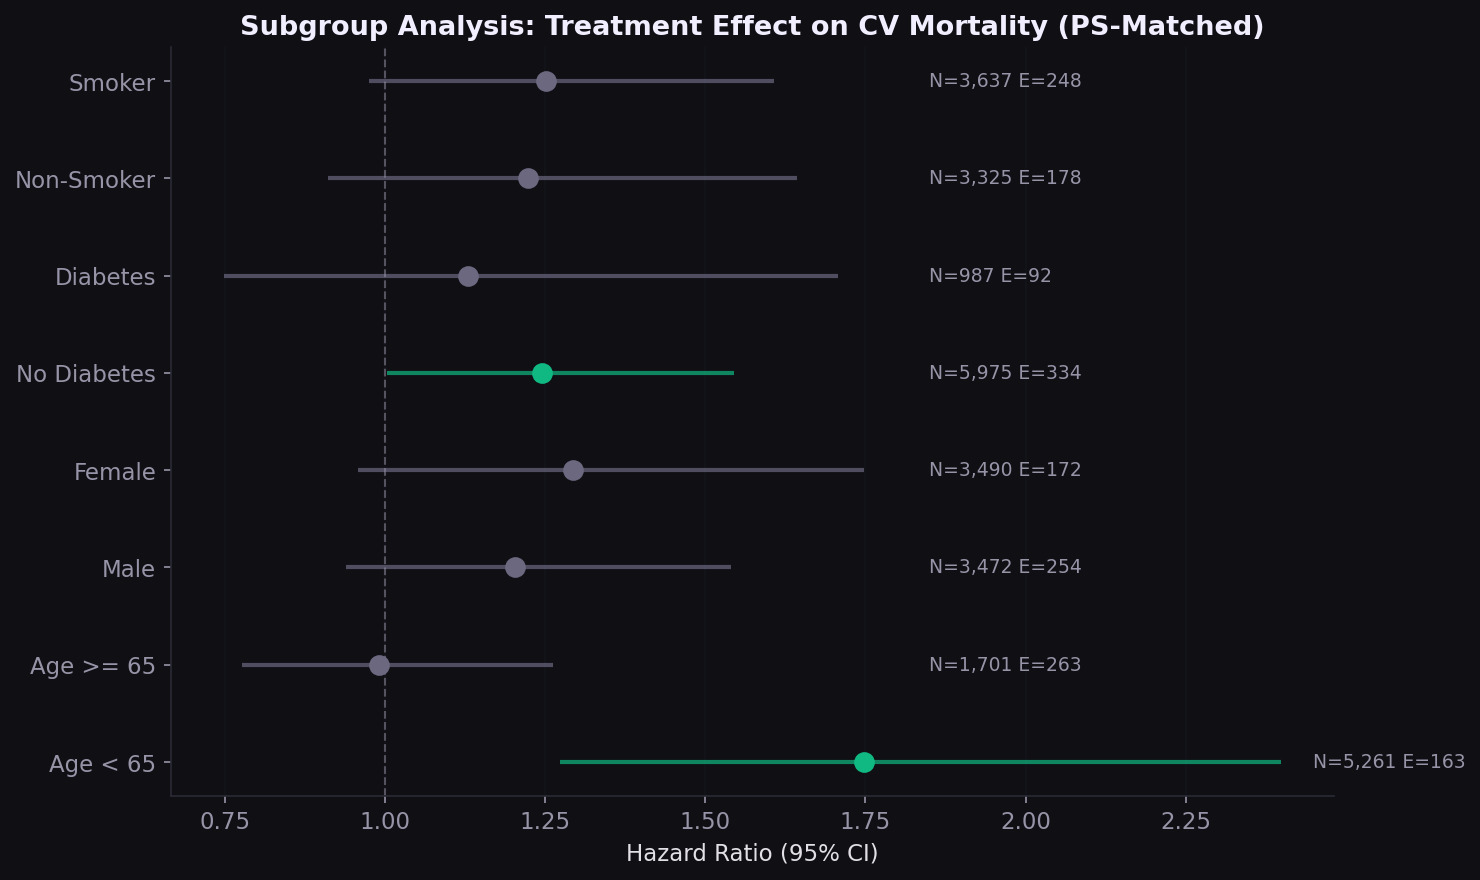

In [8]:
display(Image(filename=str(FIGURES / 'subgroup_forest_plot.png')))

**Takeaway:** The subgroup forest plot tests whether the treatment effect varies by patient characteristics. Consistent effect direction across subgroups strengthens the primary analysis. Divergence in specific subgroups (e.g., by diabetes status or age) can inform targeted treatment strategies and risk-based contracting models.

---
## Implications for HEOR and Consulting

| Finding | Implication |
|---------|------------|
| Unadjusted HR 2.86 reverses after PS adjustment | Observational claims data analyses require rigorous confounding control; unadjusted comparisons are unreliable for formulary or coverage decisions |
| HR varies from 1.02 to 1.24 across PS methods | Sensitivity analysis across multiple approaches is non-negotiable for HEOR submissions; presenting a single estimate is methodologically incomplete |
| PH assumption borderline violated (p=0.035) | Time-varying treatment effects should be explored; standard Cox models may mask delayed benefit |
| 3,481 matched pairs from 18,129 | Matching discards substantial data; IPTW preserves the full sample and may be preferable when overlap is limited |
| Self-reported treatment is a limitation | Claims-based treatment identification (NDC codes, pharmacy fills) would strengthen a real-world version of this analysis |

---

## Methods

- **Data:** NHANES 1999-2018 (10 cycles) linked to NCHS mortality files (follow-up through Dec 2019)
- **Cohort:** 18,129 adults aged 20+ with self-reported hypertension diagnosis
- **Treatment:** Self-reported antihypertensive medication use (BPQ050A)
- **Outcome:** Cardiovascular mortality (UCOD leading cause: heart disease or cerebrovascular disease)
- **Propensity model:** Logistic regression on 12 covariates (age, sex, race, education, income, BMI, diabetes, smoking, HbA1c)
- **Matching:** 1:1 nearest-neighbor on logit PS, caliper = 0.2 SD
- **IPTW:** ATE weights, trimmed at 99th percentile
- **Models:** Cox PH (unadjusted, PS-matched, IPTW, doubly robust)
- **PH test:** Schoenfeld residuals + HR-over-time rolling window
- **Tools:** Python, lifelines, scikit-learn, pandas, matplotlib

---

*Analysis by Sridharan Gopalsamy Ramaswamy | MPH/MBA, Washington University in St. Louis*